In [16]:
# Libaries
import matplotlib as mpl
import matplotlib.pyplot as plt
import scienceplots
from matplotlib.animation import FuncAnimation
from matplotlib.gridspec import GridSpec
plt.style.use(["science", "no-latex"])
import torch
import gpytorch
torch.set_default_dtype(torch.float64)
import numpy as np
import warnings
import os
import cv2
import numpy as np
import shutil
import pandas as pd


# SmallsatSim stuff
from smallsat_sim.utils.logger import Logger
import matplotlib.pyplot as plt

# Zero Order GPMPC package stuff
from zero_order_gpmpc.models.gpytorch_models.gpytorch_gp import (
    BatchIndependentMultitaskGPModel,
)

In [17]:
mpl.rcParams['font.size'] = 13  # Slightly increase the base font size
mpl.rcParams['axes.labelsize'] = 14  # Slightly increase axis label size
mpl.rcParams['axes.titlesize'] = 15  # Slightly increase plot title size
mpl.rcParams['legend.fontsize'] = 13  # Slightly increase legend font size
mpl.rcParams['xtick.labelsize'] = 13  # Slightly increase x-tick label size
mpl.rcParams['ytick.labelsize'] = 13  # Slightly increase y-tick label size

In [18]:
# Create Logger object (needed to load data)
logger = Logger()

# Load the pandas dataframe
df = logger.load_log("2024-10-22_14-38-46")
#df = logger.load_log()

# Print some information about the df
df.shape
df.info()
df.describe()

Loading log files from directory: /media/ahansson/2884-8728/logs/2024-10-22_14-38-46
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1212211 entries, 0 to 1212210
Data columns (total 20 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   RunID             1212211 non-null  int64  
 1   Timestamp         1212211 non-null  float64
 2   perturbation_log  1001 non-null     object 
 3   gp_GT             1212211 non-null  object 
 4   gp_pred           1212211 non-null  object 
 5   gp_lower          1212211 non-null  object 
 6   gp_upper          1212211 non-null  object 
 7   n_points_GP       1212211 non-null  int64  
 8   record_time       1212211 non-null  float64
 9   solve_time        1212211 non-null  float64
 10  tracking_error    1212211 non-null  float64
 11  attitude_error    1212211 non-null  float64
 12  mpc_cost          1212211 non-null  object 
 13  u_demanded        1212211 non-null  object 
 14  velocity     

,RunID,Timestamp,n_points_GP,record_time,solve_time,tracking_error,attitude_error,velocity,e_gp,e_nom
count,1.212211e+06,1.212211e+06,1.212211e+06,1.212211e+06,1.212211e+06,1.212211e+06,1.212211e+06,1.212211e+06,1.211210e+06,1.211210e+06
mean,5.000000e+02,6.050000e+01,1.171334e+02,1.217291e+01,4.069444e+01,5.078723e-02,7.840410e+00,1.710527e-01,3.727767e-04,4.080154e-03
std,2.889638e+02,3.495856e+01,1.029735e+02,1.317673e+01,9.407715e+00,1.629308e-01,2.087244e+01,5.272860e-02,1.595604e-03,7.998731e-03
min,0.000000e+00,0.000000e+00,0.000000e+00,5.580200e-02,2.754351e+01,2.978644e-07,2.461255e-04,0.000000e+00,6.306007e-08,5.548627e-09
25%,2.500000e+02,3.020000e+01,3.400000e+01,4.384391e+00,3.413223e+01,9.423170e-04,2.799897e-01,1.594689e-01,1.906569e-05,7.204360e-04
50%,5.000000e+02,6.050000e+01,7.800000e+01,7.748667e+00,3.731367e+01,4.023877e-03,8.182492e-01,1.989580e-01,6.550008e-05,1.626161e-03
75%,7.500000e+02,9.080000e+01,1.900000e+02,1.219618e+01,4.508534e+01,1.614051e-02,3.674034e+00,2.000775e-01,1.757562e-04,4.098334e-03
max,1.000000e+03,1.210000e+02,3.000000e+02,2.168431e+03,1.792179e+02,2.329847e+00,1.799932e+02,3.283555e-01,1.380121e-01,7.770201e-02


In [19]:
# Calculate and print the mean tracking error of all run ids
mean_tracking_error = df.groupby("RunID")["tracking_error"].mean()



In [20]:
# Count how many runs violoate constraints
# Group by 'RunID' and check if any tracking error in that run is larger than 1m
run_ids_with_error_gt_1m = df.groupby('RunID')['tracking_error'].apply(lambda x: (x > 1).any())

# Getting the list of RunIDs where tracking error is larger than 1m
run_ids_with_error_gt_1m = run_ids_with_error_gt_1m[run_ids_with_error_gt_1m].index.tolist()

print(f'RunIDs with tracking error larger than 1m: {run_ids_with_error_gt_1m}')


RunIDs with tracking error larger than 1m: [3, 11, 31, 37, 69, 72, 88, 122, 124, 129, 148, 149, 152, 156, 195, 204, 207, 229, 235, 252, 273, 277, 296, 330, 349, 356, 360, 377, 380, 389, 397, 407, 421, 429, 431, 434, 454, 463, 467, 480, 483, 488, 500, 519, 521, 540, 543, 548, 562, 567, 578, 584, 620, 639, 646, 650, 667, 670, 679, 687, 697, 711, 719, 721, 724, 744, 753, 757, 770, 773, 778, 790, 809, 811, 830, 833, 838, 852, 857, 868, 874, 883, 886, 893, 920, 938, 947, 971, 974, 983, 988]


Colors in the 'science' style: ['#0C5DA5', '#00B945', '#FF9500', '#FF2C00', '#845B97', '#474747', '#9e9e9e']
RunID: 3
Maximum Tracking Error: 1.217113153649257 m
Number of Perturbations: 6
Perturbation Log: [(0, 26.652985382999645, 'stuck_off'), (2, 26.652985382999645, 'stuck_off'), (7, 26.884510457444897, 'stuck_off'), (10, 28.70288176380604, 'faulty_valve (0.01, 0.29)'), (9, 15.21977028185233, 'saturated_thrust'), (1, 21.887902171211163, 'thrust_instability')]

RunID: 11
Maximum Tracking Error: 1.005418935114362 m
Number of Perturbations: 7
Perturbation Log: [(5, 14.982446551443424, 'stuck_off'), (7, 14.982446551443424, 'stuck_off'), (2, 11.30001100052603, 'stuck_off'), (11, 24.108408193597555, 'faulty_valve (0.00, 0.29)'), (8, 28.714176574875523, 'saturated_thrust'), (4, 4.7161752730779805, 'saturated_thrust'), (3, 21.558057742279733, 'thrust_instability')]

RunID: 31
Maximum Tracking Error: 1.068293610268412 m
Number of Perturbations: 6
Perturbation Log: [(4, 4.927212318220979, 'st

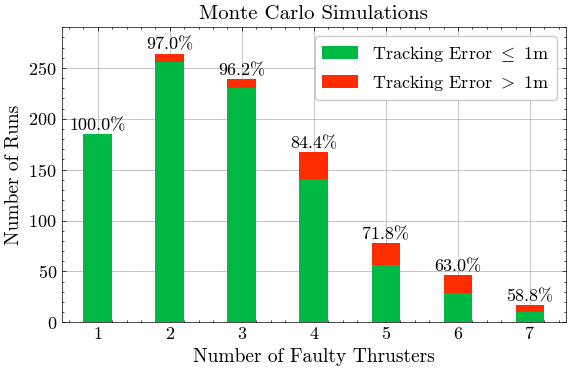

In [21]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
# Get the color cycle in the current style
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# Print the first few colors in the cycle
print(f"Colors in the 'science' style: {colors}")

# Assuming 'df' is your DataFrame

# Step 1: Extract maximum tracking error per RunID
max_tracking_error = df.groupby('RunID')['tracking_error'].max().reset_index()
max_tracking_error.rename(columns={'tracking_error': 'max_tracking_error'}, inplace=True)

# Step 2: Extract perturbation logs at timestamp 0 for each RunID
perturbation_logs = df[df['Timestamp'] == 0.0][['RunID', 'perturbation_log']]

# Step 3: Merge the two DataFrames
merged_df = pd.merge(max_tracking_error, perturbation_logs, on='RunID', how='left')

# Step 4: Filter runs with tracking error > 1m
high_error_runs = merged_df[merged_df['max_tracking_error'] > 1.0]

# Step 5: Print the perturbation logs for these runs, including the number of perturbations
if high_error_runs.empty:
    print("No runs with tracking error greater than 1 meter.")
else:
    for idx, row in high_error_runs.iterrows():
        perturbation_log = row['perturbation_log']
        
        # Count the number of perturbations
        if perturbation_log is None:
            num_perturbations = 0
        elif isinstance(perturbation_log, float) and np.isnan(perturbation_log):
            num_perturbations = 0
        elif isinstance(perturbation_log, (list, tuple, np.ndarray)):
            num_perturbations = len(perturbation_log)
        elif isinstance(perturbation_log, str):
            try:
                perturbations = ast.literal_eval(perturbation_log)
                num_perturbations = len(perturbations)
            except (ValueError, SyntaxError):
                num_perturbations = 0
        else:
            # Handle unexpected data types
            num_perturbations = 0

        print(f"RunID: {row['RunID']}")
        print(f"Maximum Tracking Error: {row['max_tracking_error']} m")
        print(f"Number of Perturbations: {num_perturbations}")
        print(f"Perturbation Log: {perturbation_log}\n")

# Step 1: Define the function to count unique faulty thrusters (as before)
def count_faulty_thrusters(log):
    if log is None:
        return 0
    if isinstance(log, float) and np.isnan(log):
        return 0
    if isinstance(log, (list, tuple, np.ndarray)):
        if len(log) == 0:
            return 0
        perturbations = log
    elif isinstance(log, str):
        try:
            perturbations = ast.literal_eval(log)
        except (ValueError, SyntaxError):
            return 0
    else:
        # If log is of an unexpected type, return 0
        return 0
    thrusters = set()
    for p in perturbations:
        try:
            thrusters.add(p[0])
        except (IndexError, TypeError):
            continue
    return len(thrusters)

# Step 2: Apply the function to count faulty thrusters
merged_df['num_faulty_thrusters'] = merged_df['perturbation_log'].apply(count_faulty_thrusters)

# Step 3: Categorize runs based on tracking error
merged_df['error_category'] = np.where(merged_df['max_tracking_error'] > 1.0, 'Above 1m', 'Below 1m')

# Step 4: Group data for the histogram
hist_data = merged_df.groupby(['num_faulty_thrusters', 'error_category']).size().unstack(fill_value=0).reset_index()

# Step 4a: Ensure 'Above 1m' and 'Below 1m' columns exist
if 'Above 1m' not in hist_data.columns:
    hist_data['Above 1m'] = 0
if 'Below 1m' not in hist_data.columns:
    hist_data['Below 1m'] = 0

# Convert counts to integers
hist_data[['Above 1m', 'Below 1m']] = hist_data[['Above 1m', 'Below 1m']].astype(int)

# Step 5: Remove x entries where no data is available
# We only keep entries where the total count is greater than zero
hist_data['Total'] = hist_data['Above 1m'] + hist_data['Below 1m']
hist_data = hist_data[hist_data['Total'] > 0]

# Calculate the success rate
hist_data['Success Rate (%)'] = (hist_data['Below 1m'] / hist_data['Total']) * 100

# Now, proceed to plot the histogram
fig, ax = plt.subplots(figsize=(6, 4))

bar_width = 0.4
index = np.arange(len(hist_data))

# Plot the stacked bars
ax.grid(zorder=0)

# Check if 'Below 1m' data is available
if hist_data['Below 1m'].sum() > 0:
    ax.bar(index, hist_data['Below 1m'], bar_width, label='Lateral Deviation $\leq$ 1m', color='#00B945', zorder=3)

# Check if 'Above 1m' data is available
if hist_data['Above 1m'].sum() > 0:
    ax.bar(index, hist_data['Above 1m'], bar_width, bottom=hist_data['Below 1m'], label='Lateral Deviation $>$ 1m', color='#FF2C00', zorder=3)

# Set labels and title
ax.set_xlabel('Number of Faulty Thrusters')
ax.set_ylabel('Number of Runs')
ax.set_title('Monte Carlo Simulations')
ax.set_xticks(index)
ax.set_xlim((-0.5,6.5))
ax.set_ylim((0,290))
ax.set_xticklabels(hist_data['num_faulty_thrusters'].astype(int))
ax.legend(framealpha=1, frameon=True)

plt.tight_layout()

# Annotate the success rate on top of each bar
for i, row in hist_data.iterrows():
    if i == 7:
        break
    success_rate = row['Success Rate (%)']
    ax.text(index[i], row['Total'] + 1, f"{success_rate:.1f}%", ha='center', va='bottom', fontsize=13, color='black', zorder=5)


plt.savefig("MC/MC_results.svg", format="svg")
plt.savefig("MC/MC_results.pdf", format="pdf")


plt.show()



In [22]:
import pandas as pd
import numpy as np
import ast
from tabulate import tabulate

# Step 2: Define a function to extract the float value from arrays
def extract_float_from_array(value):
    if isinstance(value, (list, np.ndarray)):
        if len(value) == 1:
            return value[0]
        else:
            # If the array has more than one element, decide how to handle it
            # For example, take the sum, mean, or use np.nan
            return np.nan  # or return sum(value), np.mean(value), etc.
    elif isinstance(value, (int, float, np.number)):
        return value
    elif isinstance(value, str):
        # Try to parse the string as a list or a number
        try:
            parsed_value = ast.literal_eval(value)
            if isinstance(parsed_value, (list, tuple, np.ndarray)):
                if len(parsed_value) == 1:
                    return parsed_value[0]
                else:
                    return np.nan  # Handle as needed
            elif isinstance(parsed_value, (int, float, np.number)):
                return parsed_value
            else:
                return np.nan
        except (ValueError, SyntaxError):
            return np.nan
    else:
        return np.nan

# Step 3: Apply the function to 'mpc_cost' to extract float values
df['mpc_cost'] = df['mpc_cost'].apply(extract_float_from_array)
df['mpc_cost'] = df['mpc_cost'].apply(extract_float_from_array)

# Add the constant to 'mpc_cost'
df['mpc_cost'] += 0.2 * 5e-3  # Equivalent to adding 0.001

# Calculate the cumulative cost per 'RunID'
df['cumulative_cost'] = df.groupby('RunID')['mpc_cost'].cumsum()

# Step 1: Exclude unsuccessful runs (tracking error above 1m)
max_tracking_error = df.groupby('RunID')['tracking_error'].max().reset_index()
max_tracking_error.rename(columns={'tracking_error': 'max_tracking_error'}, inplace=True)
successful_runids = max_tracking_error[max_tracking_error['max_tracking_error'] <= 1.0]['RunID'].unique()
df_successful = df[df['RunID'].isin(successful_runids)].copy()

# Step 2: Define a function to count unique faulty thrusters
def count_faulty_thrusters(log):
    if log is None or (isinstance(log, float) and np.isnan(log)):
        return 0
    try:
        if isinstance(log, str):
            perturbations = ast.literal_eval(log)
        elif isinstance(log, (list, tuple, np.ndarray)):
            perturbations = log
        else:
            return 0
        thrusters = set(p[0] for p in perturbations if isinstance(p, (list, tuple)) and len(p) > 0)
        return len(thrusters)
    except (ValueError, SyntaxError, TypeError):
        return 0

# Step 3: Get 'perturbation_log' at Timestamp == 0.0 per RunID
perturbation_logs = df[df['Timestamp'] == 0.0][['RunID', 'perturbation_log']]
perturbation_logs_successful = perturbation_logs[perturbation_logs['RunID'].isin(successful_runids)].copy()
perturbation_logs_successful['num_faulty_thrusters'] = perturbation_logs_successful['perturbation_log'].apply(count_faulty_thrusters)

# Step 4: Ensure 'e_gp' and 'e_nom' are numeric
df_successful['e_gp'] = pd.to_numeric(df_successful['e_gp'], errors='coerce')
df_successful['e_nom'] = pd.to_numeric(df_successful['e_nom'], errors='coerce')

# Step 5: Ensure 'cumulative_cost' is numeric
df_successful['cumulative_cost'] = pd.to_numeric(df_successful['cumulative_cost'], errors='coerce')

# Step 6: Get the last 'cumulative_cost' per RunID
cumulative_cost_per_run = df_successful.groupby('RunID')['cumulative_cost'].last().reset_index()

# Step 7: Compute run metrics
run_metrics = df_successful.groupby('RunID').agg({
    'tracking_error': 'mean',
    'attitude_error': 'mean',
    'e_gp': 'mean',
    'e_nom': 'mean'
}).reset_index().rename(columns={
    'tracking_error': 'tracking_error_mean',
    'attitude_error': 'attitude_error_mean',
    'e_gp': 'e_gp_mean',
    'e_nom': 'e_nom_mean'
})

# Merge 'cumulative_cost' into 'run_metrics'
run_metrics = run_metrics.merge(cumulative_cost_per_run, on='RunID', how='left')

# Merge 'num_faulty_thrusters' into 'run_metrics'
run_metrics = run_metrics.merge(
    perturbation_logs_successful[['RunID', 'num_faulty_thrusters']],
    on='RunID',
    how='left'
)

# Step 8: Group 'run_metrics' by 'num_faulty_thrusters' and compute the required metrics
table = run_metrics.groupby('num_faulty_thrusters').agg({
    'RunID': 'count',
    'tracking_error_mean': 'mean',
    'attitude_error_mean': 'mean',
    'cumulative_cost': 'mean',
    'e_gp_mean': 'mean',
    'e_nom_mean': 'mean'
}).reset_index().rename(columns={'RunID': 'Number of Runs'})

# Step 9: Convert 'num_faulty_thrusters' to string to include 'Average' row
table['num_faulty_thrusters'] = table['num_faulty_thrusters'].astype(str)

# Step 10: Compute the overall averages (last row)
overall_averages = pd.DataFrame({
    'num_faulty_thrusters': ['Average'],
    'Number of Runs': [run_metrics['RunID'].nunique()],
    'tracking_error_mean': [run_metrics['tracking_error_mean'].mean()],
    'attitude_error_mean': [run_metrics['attitude_error_mean'].mean()],
    'cumulative_cost': [run_metrics['cumulative_cost'].mean()],
    'e_gp_mean': [run_metrics['e_gp_mean'].mean()],
    'e_nom_mean': [run_metrics['e_nom_mean'].mean()]
})

# Step 11: Concatenate 'table' and 'overall_averages'
table = pd.concat([table, overall_averages], ignore_index=True)

# Step 12: Set 'num_faulty_thrusters' as the index
table.set_index('num_faulty_thrusters', inplace=True)

# Step 13: Ensure that numeric columns are of numeric type
numeric_cols = [
    'Number of Runs',
    'tracking_error_mean',
    'attitude_error_mean',
    'cumulative_cost',
    'e_gp_mean',
    'e_nom_mean'
]
for col in numeric_cols:
    table[col] = pd.to_numeric(table[col], errors='coerce')

# Step 14: Round numerical columns for better readability
table_rounded = table.copy()
table_rounded[numeric_cols] = table_rounded[numeric_cols].round(6)

# Step 15: Display the table in a pretty format
print(tabulate(table_rounded.reset_index(), headers='keys', tablefmt='psql'))

# Step 16: Export the table to LaTeX
latex_table = table.to_latex(float_format="%.6f", index=True)
print(latex_table)


+----+------------------------+------------------+-----------------------+-----------------------+-------------------+-------------+--------------+
|    | num_faulty_thrusters   |   Number of Runs |   tracking_error_mean |   attitude_error_mean |   cumulative_cost |   e_gp_mean |   e_nom_mean |
|----+------------------------+------------------+-----------------------+-----------------------+-------------------+-------------+--------------|
|  0 | 1                      |              185 |              0.017554 |               2.72532 |           1.03628 |    9.6e-05  |     0.0014   |
|  1 | 2                      |              256 |              0.019841 |               3.4467  |           1.17922 |    0.000167 |     0.002087 |
|  2 | 3                      |              230 |              0.023879 |               4.62591 |           1.35782 |    0.000269 |     0.002967 |
|  3 | 4                      |              141 |              0.037989 |               6.62002 |           2.5

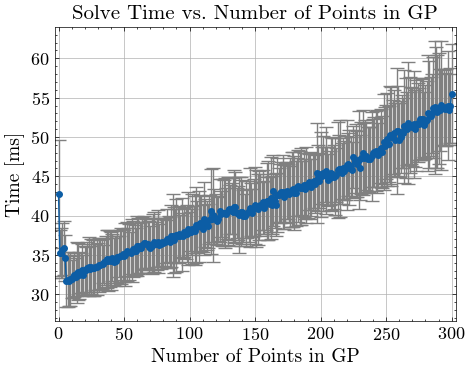

In [53]:
# Assuming 'df' is your DataFrame and 'df_successful' contains successful runs as defined earlier.

# Step 1: Ensure 'n_points_GP' and 'solve_time' are numeric
df_successful['n_points_GP'] = pd.to_numeric(df_successful['n_points_GP'], errors='coerce')
df_successful['solve_time'] = pd.to_numeric(df_successful['solve_time'], errors='coerce')

# Step 2: Remove any rows with NaN values in 'n_points_GP' or 'solve_time'
df_successful_clean = df_successful.dropna(subset=['n_points_GP', 'solve_time'])

# Step 3: Compute mean and standard deviation of 'solve_time' per 'n_points_GP'
n_points_gp_stats = df_successful_clean.groupby('n_points_GP')['solve_time'].agg(['mean', 'std', 'count']).reset_index()

# Step 4: Plot 'n_points_GP' vs average 'solve_time' with standard deviation error bars
plt.figure(figsize=(5, 4))

# Plot with error bars
plt.errorbar(
    n_points_gp_stats['n_points_GP'],
    n_points_gp_stats['mean'],
    yerr=n_points_gp_stats['std'],
    fmt='o-',  # Format line with circle markers
    capsize=5,  # Adds caps to the error bars
    ecolor='gray',  # Error bar color
    elinewidth=1,  # Error bar line width
    markeredgewidth=1,  # Marker edge width
    markersize = 4
)

plt.xlabel('Number of Points in GP')
plt.ylabel('Time [ms]')
plt.xlim((-3,303))
plt.title('Solve Time vs. Number of Points in GP')
plt.grid(True)
plt.tight_layout()

plt.savefig("MC/MC_solve_time.svg", format="svg")
plt.savefig("MC/MC_solve_time.pdf", format="pdf")


plt.show()


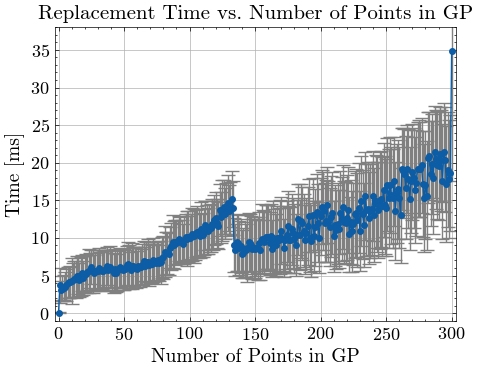

In [54]:
# Assuming 'df' is your DataFrame and 'df_successful' contains successful runs as defined earlier.

# Step 1: Ensure 'n_points_GP' and 'record_time' are numeric
df_successful['n_points_GP'] = pd.to_numeric(df_successful['n_points_GP'], errors='coerce')
df_successful['record_time'] = pd.to_numeric(df_successful['record_time'], errors='coerce')

# Step 2: Remove any rows with NaN values in 'n_points_GP' or 'record_time'
df_successful_clean = df_successful.dropna(subset=['n_points_GP', 'record_time'])

df_successful_clean = df_successful_clean[df_successful_clean['record_time'] <= 100]

# Step 3: Compute mean and standard deviation of 'record_time' per 'n_points_GP'
n_points_gp_stats = df_successful_clean.groupby('n_points_GP')['record_time'].agg(['mean', 'std', 'count']).reset_index()

# Step 4: Plot 'n_points_GP' vs average 'record_time' with standard deviation error bars
plt.figure(figsize=(5, 4))

# Plot with error bars
plt.errorbar(
    n_points_gp_stats['n_points_GP'],
    n_points_gp_stats['mean'],
    yerr=n_points_gp_stats['std'],
    fmt='o-',  # Format line with circle markers
    capsize=5,  # Adds caps to the error bars
    ecolor='gray',  # Error bar color
    elinewidth=1,  # Error bar line width
    markeredgewidth=1,  # Marker edge width
    markersize = 4
)

plt.xlabel('Number of Points in GP')
plt.ylabel('Time [ms]')
plt.xlim((-3,303))
plt.ylim((-1,38))
plt.title('Replacement Time vs. Number of Points in GP')
plt.grid(True)
plt.tight_layout()

plt.savefig("MC/MC_replacement.svg", format="svg")
plt.savefig("MC/MC_replacement.pdf", format="pdf")

plt.show()


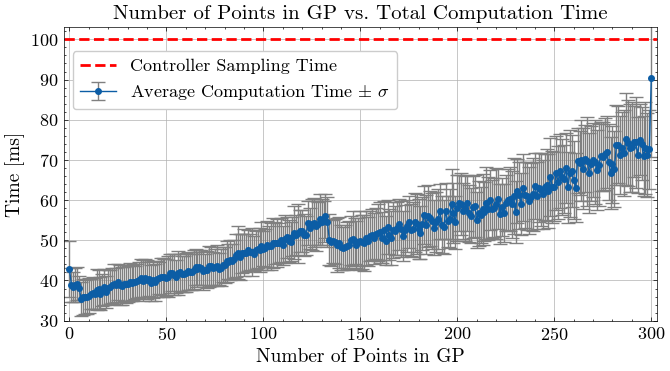

In [55]:
# Assuming 'df' is your DataFrame and 'df_successful' contains successful runs as defined earlier.

# Step 1: Ensure 'n_points_GP' and 'record_time' are numeric
df_successful['n_points_GP'] = pd.to_numeric(df_successful['n_points_GP'], errors='coerce')
df_successful['solve_time'] = pd.to_numeric(df_successful['solve_time'], errors='coerce')
df_successful['record_time'] = pd.to_numeric(df_successful['record_time'], errors='coerce')
df_successful['total_time'] = df_successful['solve_time'] + df_successful['record_time']

# Step 2: Remove any rows with NaN values in 'n_points_GP' or 'total_time'
df_successful_clean = df_successful.dropna(subset=['n_points_GP', 'total_time'])

df_successful_clean = df_successful_clean[df_successful_clean['record_time'] <= 100]

# Step 3: Compute mean and standard deviation of 'total_time' per 'n_points_GP'
n_points_gp_stats = df_successful_clean.groupby('n_points_GP')['total_time'].agg(['mean', 'std', 'count']).reset_index()

# Step 4: Plot 'n_points_GP' vs average 'total_time' with standard deviation error bars
plt.figure(figsize=(7, 4))

# Add the red dashed horizontal line at 1m for Constraint Violation
plt.axhline(y=100, color='red', linestyle='--', label='Controller Sampling Time', linewidth=2)

# Plot with error bars
plt.errorbar(
    n_points_gp_stats['n_points_GP'],
    n_points_gp_stats['mean'],
    yerr=n_points_gp_stats['std'],
    fmt='o-',  # Format line with circle markers
    capsize=5,  # Adds caps to the error bars
    ecolor='gray',  # Error bar color
    elinewidth=1,  # Error bar line width
    markeredgewidth=1,  # Marker edge width
    markersize=4,
    label = 'Average Computation Time $\pm$ $\sigma$'
)



plt.xlabel('Number of Points in GP')
plt.ylabel('Time [ms]')
plt.title('Number of Points in GP vs. Total Computation Time')
plt.xlim((-3,303))
plt.ylim((30,103))
plt.grid(True)
plt.legend(loc='upper left', facecolor='white', framealpha=1, frameon=True, bbox_to_anchor=(0, 0.95))
plt.tight_layout()

plt.savefig("MC/MC_solve_total.svg", format="svg")
plt.savefig("MC/MC_solve_total.pdf", format="pdf")

plt.show()
